# Tentando ler o sinal .mat gerado com faltas  

In [120]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq
from scipy.signal import find_peaks, windows
import math
from sklearn.linear_model import OrthogonalMatchingPursuit
import numpy as np
import pywt # PyWavelets
# import plotly.express as px

# %matplotlib widget

## Extraindo o sinal

In [121]:
mat_contents = sio.loadmat('/mnt/HD/HD/Documents/Mestrado/Dissertacao/compressive_sensing/learning_cs/FaltamonofasicaAT45km20ohm200khz.mat')

print(mat_contents.keys())

s1 = mat_contents['s1']
s2 = mat_contents['s2']
s3 = mat_contents['s3']
tempo = mat_contents['tempo'].flatten()
print(len(tempo))


dict_keys(['__header__', '__version__', '__globals__', 'tempo', 's1', 's2', 's3'])
26672


## Visualizando os sinais

As frequencias relevantes no intevalo de 0 e 150000 são:
[   480.02999311   5280.32992416  11040.68984142  16801.04975868
  22081.37968284  27841.7396001   33602.09951736  38882.42944152
  44642.78935878  50403.14927604  56163.5091933   61923.86911057
  67684.22902783  73444.58894509  79204.94886235  84965.30877961
  90725.66869688 102246.3885314  108006.74844866]


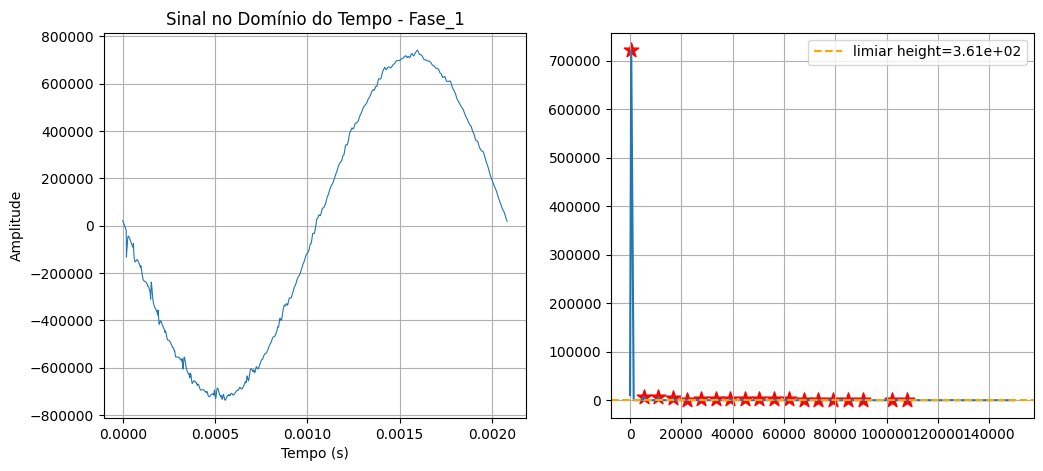

As frequencias relevantes no intevalo de 0 e 150000 são:
[  480.02999311  5280.32992416 11040.68984142 16801.04975868
 22081.37968284 27841.7396001  33602.09951736 38882.42944152
 44642.78935878 50403.14927604 56163.5091933  61923.86911057
 67684.22902783 79204.94886235 84965.30877961]


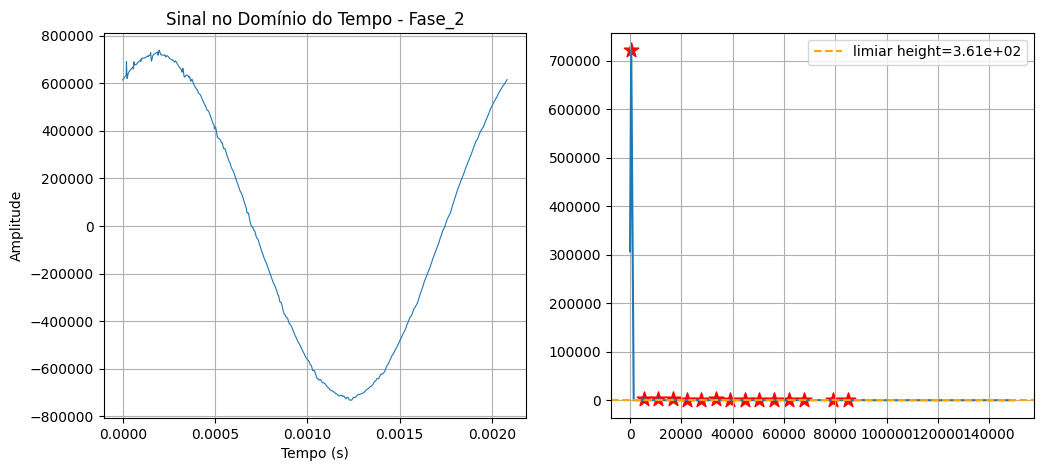

As frequencias relevantes no intevalo de 0 e 150000 são:
[  480.02999311  5280.32992416 11040.68984142 16801.04975868
 22081.37968284 27841.7396001  33602.09951736 38882.42944152
 44642.78935878 50403.14927604 56163.5091933  61923.86911057
 67684.22902783 79204.94886235 84965.30877961]


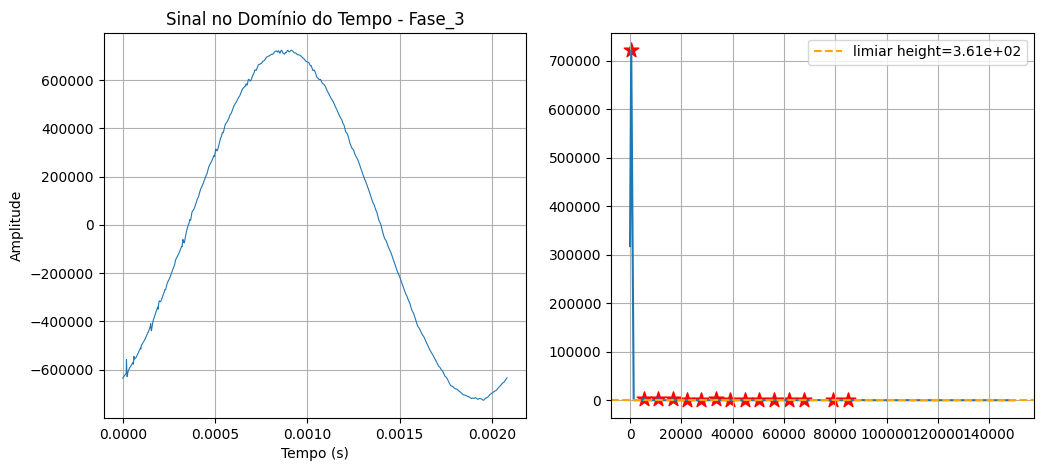

In [122]:
# seus sinais: sinal (1D numpy)
# tempo vetores: tempo_sinal já ok
dt = np.mean(np.diff(tempo))  # ou use seu dt já calculado
Fs = 1.0 / dt


def analyze_and_plot(sinal, tempo, nome, apply_window=True, peak_rel_threshold=0.05):
    N = len(sinal)
    # 1) remover média para eliminar DC indesejado (opcional)
    sinal_zero_mean = sinal - np.mean(sinal)

    # 2) aplicar janela para reduzir leakage (opcional)
    if apply_window:
        win = windows.hann(N)
        sinal_win = sinal_zero_mean * win
        # correção de amplitude pela janela (normalizar energia)
        coherent_gain = np.sum(win) / N
    else:
        sinal_win = sinal_zero_mean
        coherent_gain = 1.0

    # 3) FFT unilateral (apenas frequências >=0)
    fft_vals = np.fft.rfft(sinal_win)
    freqs = np.fft.rfftfreq(N, d=dt)  # d = dt é claro e simples

    # 4) magnitude e normalização
    mag = np.abs(fft_vals) / N  # normaliza por N
    # multiplicar por 2 para recuperar energia do lado negativo (exceto DC e Nyquist)
    mag[1:-1] *= 2.0
    # compensar ganho da janela
    mag /= coherent_gain

    # 5) plot domínio do tempo e espectro (linear e em dB)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(tempo, sinal, linewidth=0.8)
    plt.title(f"Sinal no Domínio do Tempo - {nome}")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.grid()

    # 6) detectar picos significativos

    # Ajustando a janela de frequencias à analisar (remover DC -> Hz)
    fmin, fmax = 0, 150000
    mask = (freqs >= fmin) & (freqs <= fmax)
    freqs_sel = freqs[mask]
    mag_sel = mag[mask]
    
    # limiar relativo (ex.: 5% do máximo dentro da faixa selecionada)
    rel_height = 0.0005 * np.max(mag_sel)
    
    # Busque os picos apenas no intervalo de fmin, fmax
    peaks, props = find_peaks(mag_sel, height=rel_height, prominence=0.00000002*np.max(mag_sel))
    
    # Converter para frequencias reais
    peak_freqs = freqs_sel[peaks]
    peak_mags = mag_sel[peaks]
    
    print(f"As frequencias relevantes no intevalo de {fmin} e {fmax} são:")
    print(peak_freqs)
    
    # Plotando as frequencias
    # plt.subplot(1, 2, 2)
    # plt.plot(freqs_sel, mag_sel, linewidth=0.8)
    # plt.scatter(peak_freqs, peak_mags, color="red", marker="*", s=100, label="Picos")
    # plt.title(f"Espectro Unilateral - {nome}")
    # plt.xlabel("Frequência (Hz)")
    # plt.ylabel("Magnitude (linear)")
    # plt.legend()
    # plt.grid()
    # plt.tight_layout()
    
    # plt.figure(figsize=(10,4))
    plt.subplot(1,2,2)
    plt.plot(freqs_sel, mag_sel)
    plt.axhline(rel_height, color='orange', linestyle='--', label=f"limiar height={rel_height:.2e}")
    plt.scatter(freqs_sel[peaks], mag_sel[peaks], color='red', marker='*', s=120)
    plt.legend()
    plt.grid()
    plt.show()

    return freqs, mag, peak_freqs, peak_mags

# exemplo de uso para cada sinal (assumindo signals e nomes definidos)
informacoes_sinais = {}
signals = [s1[:,0], s2[:,0], s3[:,0]]
for i, sinal in enumerate(signals):
    N = len(sinal)
    tempo_sinal = np.arange(N) * dt
    freqs, mag, peak_freqs, peak_mags = analyze_and_plot(
        sinal, tempo_sinal, f"Fase_{i+1}", apply_window=True, peak_rel_threshold=0.05
    )
    i_sinal = {
        "sinal_ch1": sinal,
        "freqs": freqs,
        "mag": mag,
        "peak_freqs": peak_freqs,
        "peak_mags": peak_mags
    }
    informacoes_sinais[f"Fase_{i+1}"] = i_sinal
    
# TODO: Adicionar frequencia de 60 Hz nas frequencias principais - isso pode estar causando o erro na reconstrução

## Determinando o tamanho ideal da amostra M

In [123]:
S = len(informacoes_sinais['Fase_1']['peak_freqs'])+1
# N = len(informacoes_sinais['Fase_1']['sinal_ch1'])
N = len(informacoes_sinais['Fase_1']['sinal_ch1'])
print(f"S = {S}")
print(f"N = {N}")
C = 2

M = round(C*S*math.log10(N/S))
print(f"M = {M}")

S = 20
N = 3334
M = 89


## Calculando diferentes matrizes de phi

In [124]:
# phi_gaussiana = np.random.normal(size=(M,N))
# Normalização de phi
phi_gaussiana = np.random.randn(M, N) 
phi_gaussiana = phi_gaussiana / np.sqrt(N)

phi_bernoulli = np.random.choice([1/(math.sqrt(M)), -1/(math.sqrt(M))], size=(M,N))

## Amostragem esparsa do sinal

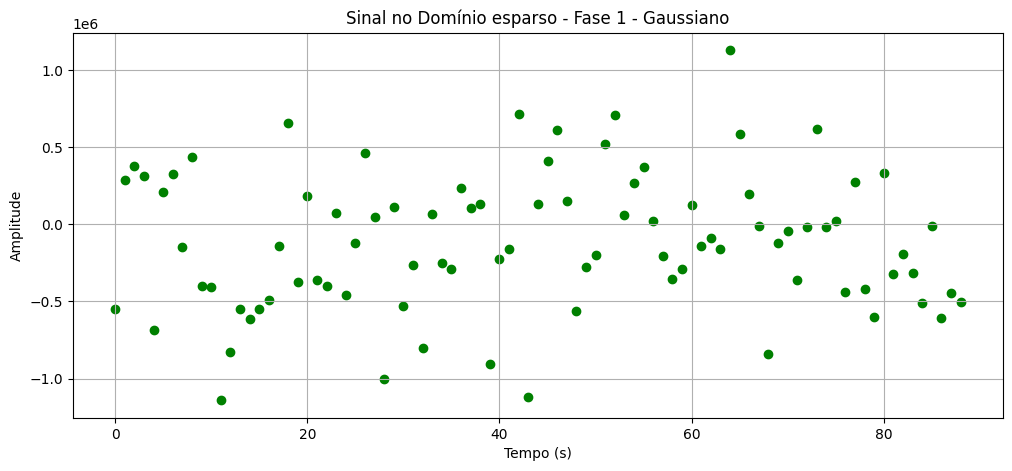

In [125]:
y_gaussiano = phi_gaussiana@informacoes_sinais['Fase_1']['sinal_ch1']

plt.figure(figsize=(12, 5))
plt.scatter(np.arange(len(y_gaussiano)),y_gaussiano, color='green', marker='o')
plt.title(f"Sinal no Domínio esparso - Fase 1 - Gaussiano")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

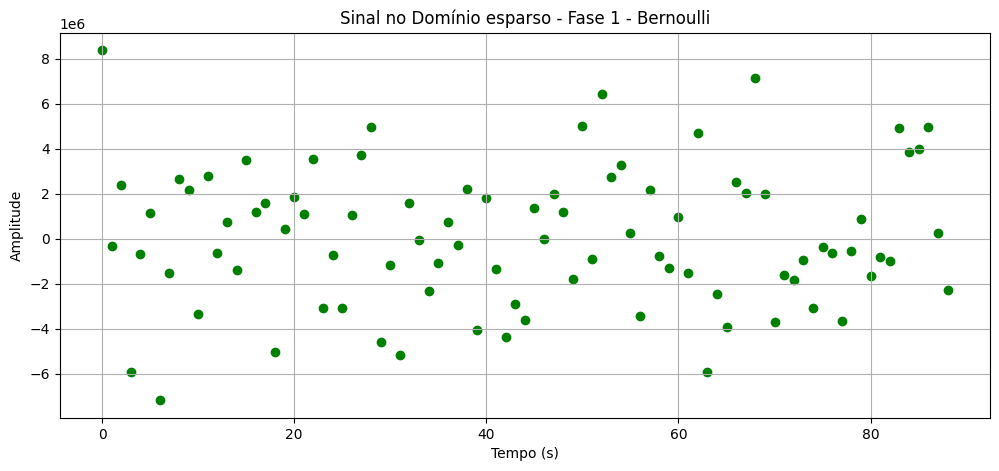

In [126]:
y_bernoulli = phi_bernoulli@informacoes_sinais['Fase_1']['sinal_ch1']

plt.figure(figsize=(12, 5))
plt.scatter(np.arange(len(y_bernoulli)),y_bernoulli, color='green', marker='o')
plt.title(f"Sinal no Domínio esparso - Fase 1 - Bernoulli")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

## Obtendo a matriz Psi para o cálculo de A com wavelet e identidade concatenadas

In [127]:
import numpy as np
import pywt

def build_wavelet_matrix(N, wavelet='db4', level=3):
    # cria átomo para cada coeficiente da wavedec
    zero = np.zeros(N)
    coeffs_template = pywt.wavedec(zero, wavelet, level=level)
    idx_map = []
    for i, arr in enumerate(coeffs_template):
        for j in range(arr.size):
            idx_map.append((i,j))
    Psi = np.zeros((N, len(idx_map)))
    for k,(iarr,jpos) in enumerate(idx_map):
        coeffs = [np.copy(a) for a in coeffs_template]
        coeffs[iarr][jpos] = 1.0
        atom = pywt.waverec(coeffs, wavelet)
        Psi[:, k] = atom[:N]
    return Psi

x_original = informacoes_sinais['Fase_1']['sinal_ch1']
N = x_original.size
I = np.eye(N)
Psi_wave = build_wavelet_matrix(N, wavelet='db1', level=2)   # teste db1
Psi = np.concatenate([I, Psi_wave], axis=1)  # N x (N + K)

# Teste de esparsidade

In [128]:
import pywt, numpy as np

def sparsity_stats(x, wavelet='db4', level=None):
    if level is None:
        level = pywt.dwt_max_level(len(x), pywt.Wavelet(wavelet).dec_len)
    coeffs = pywt.wavedec(x, wavelet, level=level)
    arr = np.concatenate([c.ravel() for c in coeffs])
    arr_abs = np.sort(np.abs(arr))[::-1]
    energy = np.cumsum(arr_abs**2) / np.sum(arr_abs**2)
    k90 = np.searchsorted(energy, 0.90) + 1
    k99 = np.searchsorted(energy, 0.99) + 1
    return {'N_coeffs': arr.size, 'k90': int(k90), 'k99': int(k99)}

x_original = informacoes_sinais['Fase_1']['sinal_ch1']
print(sparsity_stats(x_original, wavelet='db1', level=3))


{'N_coeffs': 3335, 'k90': 249, 'k99': 341}


## Reconstrução do sinal esparso usando a phi gaussiano

### Calculando S (esparsidade)

In [129]:
# 1. Transforme o sinal original (x) para o domínio esparso (s_original)
# Adapte esta parte para a sua estrutura de pywt.wavedec (que retorna uma lista de coeficientes)
s_coeffs_original = pywt.wavedec(sinal, wavelet_name, level=level)
s_flat_original = np.concatenate([c.flatten() for c in s_coeffs_original])

# 2. Encontre S baseado na energia
# Defina um limite (threshold) que represente S% da energia
threshold_ratio = 0.95  # Ex: 99% da energia

# Coeficientes ordenados pelo valor absoluto
s_sorted = np.sort(np.abs(s_flat_original))[::-1] 
cumulative_energy = np.cumsum(s_sorted**2)
total_energy = cumulative_energy[-1]

# Encontre o índice S onde a energia acumulada atinge threshold_ratio
S_calculado = np.argmax(cumulative_energy >= threshold_ratio * total_energy) + 1

### Obtendo a matriz A

In [130]:
# Supondo que você já tem Phi (M x N)
M, N = phi_gaussiana.shape

# Matriz de medição
A = phi_gaussiana.dot(Psi)

# Normaliza colunas
col_norms = np.linalg.norm(A, axis=0)
col_norms[col_norms == 0] = 1.0
A_norm = A / col_norms

# Vetor de medições
y = phi_gaussiana.dot(x_original)  # equivalente a x_original[meas_idx]


### Abordagem de reconstrução usando a matriz gaussiana

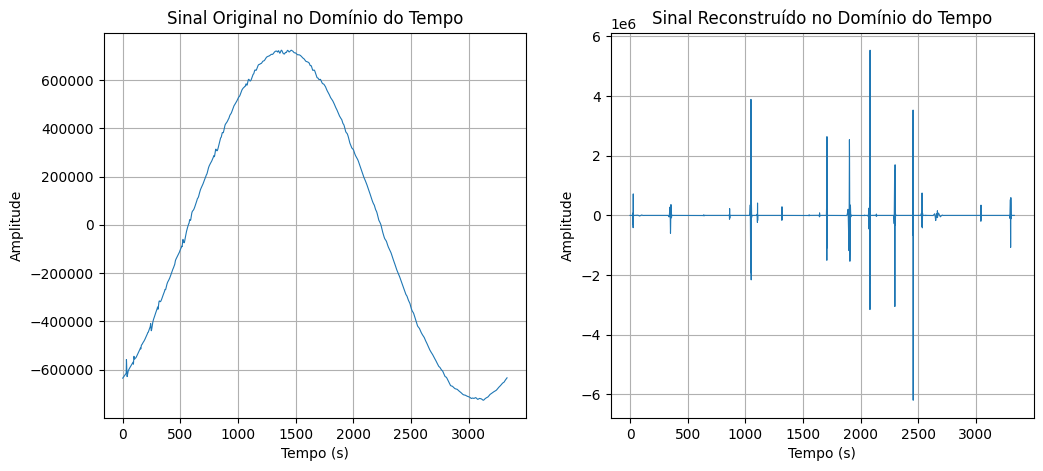

In [131]:
# Calcular a Matriz de Sensing A
A = phi_gaussiana @ Psi
# A tem dimensão (M x N_sparse)

# S = int(0.1*N)# Chute de esparsidade -> S refere-se ao número de coeficientes Wavelet grandes
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=S_calculado)
omp.fit(A,y_gaussiano)
s_reconstruido_flat = omp.coef_

# Reconstruindo o sinal
# 1. Reestruturar s_reconstruido_flat (vetor plano) na estrutura de coeficientes Wavelet (lista de arrays)
s_reconstruido_coeffs = []
current_idx = 0

# A estrutura deve ser a mesma obtida ao aplicar pywt.wavedec em um vetor de zeros
temp_s = np.zeros(N)
example_coeffs = pywt.wavedec(temp_s, wavelet_name, level=level)

for c in example_coeffs:
    band_len = len(c)
    # Extrai o segmento de s_reconstruido_flat correspondente à banda
    s_reconstruido_coeffs.append(s_reconstruido_flat[current_idx : current_idx + band_len])
    current_idx += band_len

# 2. Aplicar a Transformada Wavelet Inversa (IDWT)
x_reconstruido = pywt.waverec(s_reconstruido_coeffs, wavelet_name)

# 3. Comparar o resultado
# x_reconstruido é o seu sinal elétrico reconstruído com base nas suas poucas medições (y).
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.arange(N), sinal, linewidth=0.8)
# plt.plot(np.arange(N), x_reconstruido, color='r', linewidth=0.8)
plt.title(f"Sinal Original no Domínio do Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(1,2,2)
plt.plot(np.arange(N), x_reconstruido, linewidth=0.8)
plt.title(f"Sinal Reconstruído no Domínio do Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

### Abordagem de reconstrução usando phi de bernoulli

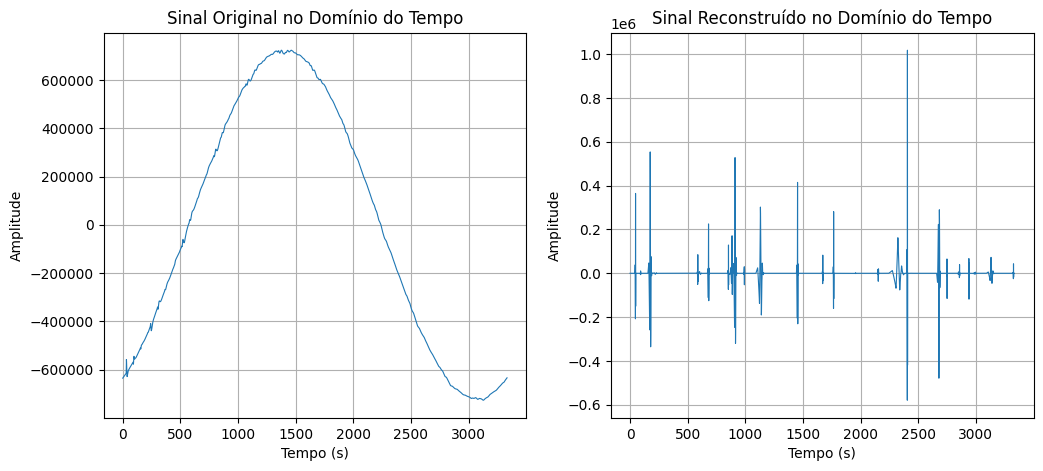

In [132]:
# Calcular a Matriz de Sensing A
A = phi_bernoulli @ Psi
# A tem dimensão (M x N_sparse)

# S = int(0.1*N)# Chute de esparsidade -> S refere-se ao número de coeficientes Wavelet grandes
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=S_calculado)
omp.fit(A,y_gaussiano)
s_reconstruido_flat = omp.coef_

# Reconstruindo o sinal
# 1. Reestruturar s_reconstruido_flat (vetor plano) na estrutura de coeficientes Wavelet (lista de arrays)
s_reconstruido_coeffs = []
current_idx = 0

# A estrutura deve ser a mesma obtida ao aplicar pywt.wavedec em um vetor de zeros
temp_s = np.zeros(N)
example_coeffs = pywt.wavedec(temp_s, wavelet_name, level=level)

for c in example_coeffs:
    band_len = len(c)
    # Extrai o segmento de s_reconstruido_flat correspondente à banda
    s_reconstruido_coeffs.append(s_reconstruido_flat[current_idx : current_idx + band_len])
    current_idx += band_len

# 2. Aplicar a Transformada Wavelet Inversa (IDWT)
x_reconstruido = pywt.waverec(s_reconstruido_coeffs, wavelet_name)

# 3. Comparar o resultado
# x_reconstruido é o seu sinal elétrico reconstruído com base nas suas poucas medições (y).
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.arange(N), sinal, linewidth=0.8)
# plt.plot(np.arange(N), x_reconstruido, color='r', linewidth=0.8)
plt.title(f"Sinal Original no Domínio do Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(1,2,2)
plt.plot(np.arange(N), x_reconstruido, linewidth=0.8)
plt.title(f"Sinal Reconstruído no Domínio do Tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.show()

## Reconstrução comparando OMP e Lasso

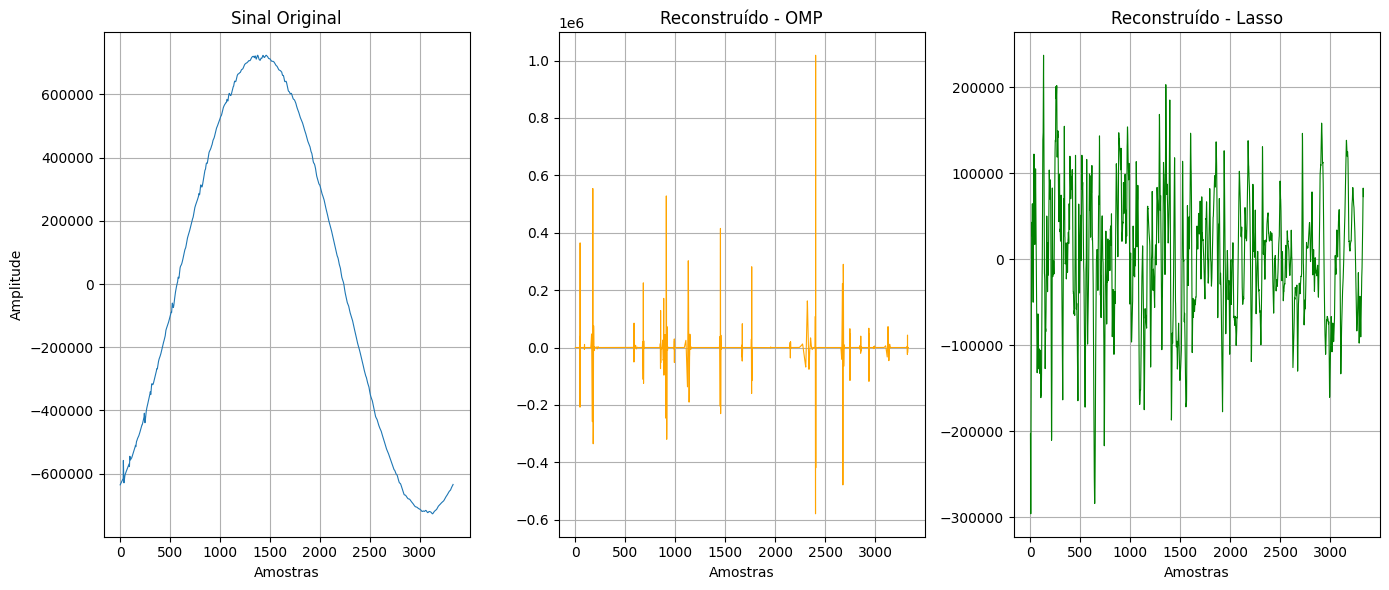

In [133]:
from sklearn.linear_model import OrthogonalMatchingPursuit, Lasso

# -------------------------------
# Reconstrução com OMP ou Lasso
# -------------------------------
def reconstruir_sinal(A, y_gaussiano, N, wavelet_name, level, metodo="OMP",
                      S_calculado=None, alpha=1e-3):
    """
    metodo = "OMP" ou "Lasso"
    S_calculado = número de coeficientes não-nulos (para OMP)
    alpha = parâmetro de regularização (para Lasso)
    """
    
    if metodo == "OMP":
        if S_calculado is None:
            raise ValueError("Para OMP é necessário fornecer S_calculado")
        modelo = OrthogonalMatchingPursuit(n_nonzero_coefs=S_calculado)
        modelo.fit(A, y_gaussiano)
        s_reconstruido_flat = modelo.coef_

    elif metodo == "Lasso":
        modelo = Lasso(alpha=alpha, max_iter=5000, fit_intercept=False)
        modelo.fit(A, y_gaussiano)
        s_reconstruido_flat = modelo.coef_

    else:
        raise ValueError("Método não reconhecido. Use 'OMP' ou 'Lasso'.")

    # -------------------------------
    # Reestruturar os coeficientes em forma de listas para IDWT
    # -------------------------------
    s_reconstruido_coeffs = []
    current_idx = 0

    # Estrutura wavelet de referência
    temp_s = np.zeros(N)
    example_coeffs = pywt.wavedec(temp_s, wavelet_name, level=level)

    for c in example_coeffs:
        band_len = len(c)
        s_reconstruido_coeffs.append(
            s_reconstruido_flat[current_idx : current_idx + band_len]
        )
        current_idx += band_len

    # Reconstrução no tempo
    x_reconstruido = pywt.waverec(s_reconstruido_coeffs, wavelet_name)

    return x_reconstruido, s_reconstruido_flat


# -------------------------------
# Exemplo de uso
# -------------------------------
# O sinal original é 'sinal'
# A matriz de medição é 'A'
# As medições são 'y_gaussiano'
# N = len(sinal)
level = 5
wavelet_name = 'db3'
# --- Usando OMP ---
x_recon_omp, coef_omp = reconstruir_sinal(A, y_gaussiano, N, wavelet_name, level,
                                          metodo="OMP", S_calculado=S_calculado)

# --- Usando Lasso ---
x_recon_lasso, coef_lasso = reconstruir_sinal(A, y_gaussiano, N, wavelet_name, level,
                                              metodo="Lasso", alpha=1e-3)


# -------------------------------
# Plot comparativo
# -------------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.plot(np.arange(N), sinal, linewidth=0.8)
plt.title("Sinal Original")
plt.xlabel("Amostras")
plt.ylabel("Amplitude")
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(np.arange(N), x_recon_omp, linewidth=0.8, color="orange")
plt.title("Reconstruído - OMP")
plt.xlabel("Amostras")
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(np.arange(N), x_recon_lasso, linewidth=0.8, color="green")
plt.title("Reconstruído - Lasso")
plt.xlabel("Amostras")
plt.grid()

plt.tight_layout()
plt.show()


### Método organizado de OMP e Lasso

/mnt/HD/HD/Documents/Mestrado/Dissertacao/compressive_sensing/.venv/lib/python3.11/site-packages/sklearn/linear_model/_omp.py:445: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  out = _cholesky_omp(


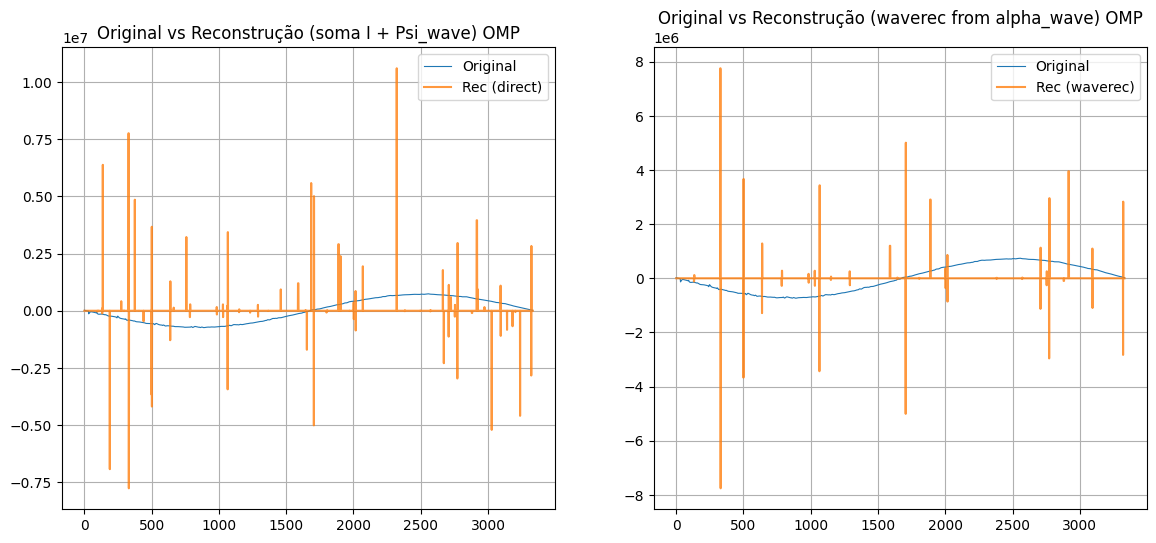

In [134]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from sklearn.linear_model import OrthogonalMatchingPursuit, Lasso

# -------------------------
# 1) Função para construir Psi_wave (matriz que mapeia coeficientes wavelet -> sinal no tempo)
#    Também retorna "shapes" (lista de comprimentos de cada banda) para converter flat->lista p/ waverec
# -------------------------
def build_wavelet_matrix_and_shapes(N, wavelet='db1', level=None):
    if level is None:
        level = pywt.dwt_max_level(N, pywt.Wavelet(wavelet).dec_len)
    zero = np.zeros(N)
    coeffs_template = pywt.wavedec(zero, wavelet, level=level)
    shapes = [c.size for c in coeffs_template]    # comprimento de cada banda na ordem do wavedec
    # total coeficientes
    K = sum(shapes)
    Psi = np.zeros((N, K))
    idx = 0
    for band_idx, band_len in enumerate(shapes):
        for j in range(band_len):
            coeffs = [np.copy(a) for a in coeffs_template]
            coeffs[band_idx][j] = 1.0
            atom = pywt.waverec(coeffs, wavelet)
            atom = atom[:N]
            Psi[:, idx] = atom
            idx += 1
    return Psi, shapes

# -------------------------
# 2) Função principal de reconstrução (usa Phi diretamente)
# -------------------------
def reconstruct_with_omp_or_lasso(Phi, sinal, wavelet_name='db1', level=None,
                                 method='OMP', S_calculado=None, alpha=1e-3):
    """
    Phi: (M x N) measurement matrix (já construída)
    sinal: original time-domain signal (N,) - usado para computar y e MSE (se disponível)
    method: 'OMP' or 'Lasso'
    S_calculado: int number of nonzeros for OMP (required if method=='OMP')
    alpha: regularization for Lasso
    Returns: x_rec (N,), alpha_full (N+K,), diagnostics dict
    """
    N = sinal.size
    y = Phi.dot(sinal)   # medições (M,)
    M = y.size

    # build wavelet dictionary (Psi_wave: N x K, shapes list)
    Psi_wave, shapes = build_wavelet_matrix_and_shapes(N, wavelet=wavelet_name, level=level)
    K = Psi_wave.shape[1]

    # concatenated dictionary Psi = [I | Psi_wave]
    I = np.eye(N)
    Psi = np.concatenate([I, Psi_wave], axis=1)   # N x (N+K)

    # sensing matrix A = Phi @ Psi  (M x (N+K))
    A = Phi.dot(Psi)

    # debug checks
    diag = {}
    diag['A_shape'] = A.shape
    diag['Psi_shape'] = Psi.shape
    diag['N'] = N
    diag['K'] = K
    diag['M'] = M

    # normalize columns of A (important)
    col_norms = np.linalg.norm(A, axis=0)
    col_norms[col_norms == 0] = 1.0
    A_norm = A / col_norms

    # choose solver
    if method.upper() == 'OMP':
        if S_calculado is None:
            raise ValueError("Para OMP forneça S_calculado")
        model = OrthogonalMatchingPursuit(n_nonzero_coefs=S_calculado)
        model.fit(A_norm, y)
        coef_norm = model.coef_.copy()
    elif method.upper() == 'LASSO':
        model = Lasso(alpha=alpha, max_iter=10000, fit_intercept=False)
        model.fit(A_norm, y)
        coef_norm = model.coef_.copy()
    else:
        raise ValueError("method deve ser 'OMP' ou 'LASSO'")

    # des-normalizar coeficientes
    alpha_full = coef_norm / col_norms   # length N + K

    # separar parte identidade e parte wavelet
    alpha_I = alpha_full[:N]        # contribuição delta / spikes
    alpha_wave = alpha_full[N:]     # coeficientes da base wavelet (flat)

    # reconstrução direta (soma das duas contribuições)
    x_rec_direct = alpha_I + Psi_wave.dot(alpha_wave)

    # se quiser reconstruir via pywt.waverec usando estruturas de bandas:
    # transformar alpha_wave (flat) -> lista de arrays com shapes
    s_coeffs = []
    cur = 0
    for l in shapes:
        s_coeffs.append(alpha_wave[cur:cur+l].copy())
        cur += l
    # IDWT (pode dar comprimento ligeiramente > N devido a padding; truncar)
    x_rec_waverec = pywt.waverec(s_coeffs, wavelet_name)[:N]

    # métrica
    mse_direct = np.mean((sinal - x_rec_direct)**2)
    mse_waverec = np.mean((sinal - x_rec_waverec)**2)

    diag.update({
        'mse_direct': float(mse_direct),
        'mse_waverec': float(mse_waverec),
        'col_norms_min': float(col_norms.min()),
        'col_norms_max': float(col_norms.max())
    })

    return {
        'x_rec_direct': x_rec_direct,
        'x_rec_waverec': x_rec_waverec,
        'alpha_full': alpha_full,
        'alpha_I': alpha_I,
        'alpha_wave_flat': alpha_wave,
        's_coeffs_list': s_coeffs,
        'diagnostics': diag
    }

# -------------------------
# 4) Plot rápido para comparar (após obter resultado)
# -------------------------
def plot_results(sinal, resultado, title_suffix=''):
    N = sinal.size
    x1 = resultado['x_rec_direct']
    x2 = resultado['x_rec_waverec']
    plt.figure(figsize=(14,6))
    plt.subplot(1,2,1)
    plt.plot(np.arange(N), sinal, label='Original', linewidth=0.8)
    plt.plot(np.arange(N), x1, label='Rec (direct)', alpha=0.8)
    plt.title('Original vs Reconstrução (soma I + Psi_wave) ' + title_suffix)
    plt.legend()
    plt.grid()
    plt.subplot(1,2,2)
    plt.plot(np.arange(N), sinal, label='Original', linewidth=0.8)
    plt.plot(np.arange(N), x2, label='Rec (waverec)', alpha=0.8)
    plt.title('Original vs Reconstrução (waverec from alpha_wave) ' + title_suffix)
    plt.legend()
    plt.grid()
    plt.show()
    
# -------------------------
# 3) Exemplo de uso (ajuste nomes conforme seu código)
# -------------------------
# supondo que você já tenha Phi (M x N), sinal (N,), e queira rodar:
sinal_original = informacoes_sinais['Fase_1']['sinal_ch1']
# método OMP
resultado_omp = reconstruct_with_omp_or_lasso(phi_gaussiana, sinal_original, wavelet_name='db1', level=2, method='OMP', S_calculado=250)
plot_results(sinal_original, resultado_omp, "OMP")
# método Lasso
# resultado_lasso = reconstruct_with_omp_or_lasso(Phi, sinal, wavelet_name='db1', level=2, method='LASSO', alpha=1e-3)


